In [21]:
from pathlib import Path
from functools import lru_cache
from numbers import Integral
import importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

# 通常 notebook 的工作目录就是 9.21；也支持从项目根目录打开。
_candidates = [
    Path.cwd(),
    Path.cwd() / "9.21",
    Path("/Users/jinlingxiao123/Downloads/Research Project/BKT-plasma2D/9.21"),
]
BASE_DIR = next((p.resolve() for p in _candidates
                 if (p / "read_scan.py").is_file() and (p / "Data").is_dir()), None)
if BASE_DIR is None:
    raise FileNotFoundError("未找到 9.21/read_scan.py 和 Data，请在本代码块设置 BASE_DIR。")
DATA_DIR = BASE_DIR / "Data"

_spec = importlib.util.spec_from_file_location("scan_reader_921", BASE_DIR / "read_scan.py")
_reader = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_reader)
load_run = _reader.load_run

# 这里只读取小体积的参数表，选中动画后才读取该点的坐标。
_tables = []
for path in sorted(DATA_DIR.rglob("states.csv")):
    batch = path.parent
    required = ["metadata.toml", "coordinates.f64", "charges.f64", "samples.csv", "progress.csv"]
    missing = [name for name in required if not (batch / name).is_file()]
    if missing:
        raise FileNotFoundError(f"批次文件不完整：{batch}，缺少 {missing}")
    table = pd.read_csv(path)
    table["batch_dir"] = str(batch.resolve())
    _tables.append(table)
if not _tables:
    raise FileNotFoundError(f"{DATA_DIR} 下没有已解压的 states.csv。")
states = pd.concat(_tables, ignore_index=True).sort_values(["state_id", "replicate_id"])
_required_columns = ["state_id", "run_id", "replicate_id", "N", "rho_star", "T_star", "E0_star",
                     "seed", "initial_condition", "Lx", "Ly", "n_samples_planned"]
_missing_columns = set(_required_columns) - set(states.columns)
if _missing_columns:
    raise ValueError(f"参数表缺少列：{sorted(_missing_columns)}")
print(f"已索引 {len(states)} 次运行，来自 {len(_tables)} 个批次。")
for name in ("N", "rho_star", "T_star", "E0_star", "replicate_id"):
    print(f"{name}: {sorted(states[name].unique().tolist())}")

已索引 1210 次运行，来自 10 个批次。
N: [50]
rho_star: [0.001, 0.002, 0.005, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.2]
T_star: [0.15, 0.17, 0.19, 0.21, 0.23, 0.25, 0.27, 0.29, 0.31, 0.33, 0.35]
E0_star: [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
replicate_id: [1]


In [22]:
def select_state(*, N=50, rho_star=0.005, T_star=0.19, E0_star=0.2,
                 replicate_id=1, state_id=None):
    """按物理参数选择；给定 state_id 时，它覆盖 N、rho_star、T_star、E0_star。"""
    mask = states["replicate_id"].eq(replicate_id)
    if state_id is None:
        mask &= (states["N"].eq(N)
                 & np.isclose(states["rho_star"], rho_star, rtol=0, atol=1e-12)
                 & np.isclose(states["T_star"], T_star, rtol=0, atol=1e-12)
                 & np.isclose(states["E0_star"], E0_star, rtol=0, atol=1e-12))
    else:
        mask &= states["state_id"].eq(state_id)
    found = states.loc[mask]
    if len(found) == 0:
        raise ValueError("没有匹配的参数点，请检查上面列出的取值；例如本次 T*=0.19、0.21，没有 0.20。")
    if len(found) > 1:
        raise ValueError("匹配到多个批次中的重复运行；请将 DATA_DIR 限定为想查看的数据目录后重新运行索引代码块。")
    row = found.iloc[0]
    if not np.isclose(float(row["Lx"]), 1) or not np.isclose(float(row["Ly"]), 1):
        raise ValueError("此动画使用单位盒坐标，目前只支持 Lx=Ly=1。")
    return row


@lru_cache(maxsize=2)
def load_animation_data(batch_dir, state_id, replicate_id):
    data = load_run(batch_dir, state_id, replicate_id)  # 默认只接受完整运行
    xy, q = data["coordinates"], data["charges"]
    if xy.shape != (len(data["sample"]), len(q), 2):
        raise ValueError("坐标数组形状与采样数或粒子数不一致。")
    if not np.isfinite(xy).all() or not ((xy >= 0) & (xy < 1)).all():
        raise ValueError("坐标必须是单位周期盒中的有限数值 [0,1)。")
    return xy, q, data["sample"], data["production_sweep"], data["total_sweep"]


def animate_state(*, N=50, rho_star=0.005, T_star=0.19, E0_star=0.2,
                  replicate_id=1, state_id=None, frame_stride=5,
                  sample_start=1, sample_stop=None, interval_ms=80, embed_limit_mb=100):
    """生成一段动画。sample_start/stop 是保存的帧序号，首尾均包含，并非 sweep。
    frame_stride=5：1000 个保存帧中显示约 200 帧；设为 1 则显示全部。
    """
    row = select_state(N=N, rho_star=rho_star, T_star=T_star, E0_star=E0_star,
                       replicate_id=replicate_id, state_id=state_id)
    if not isinstance(frame_stride, Integral) or isinstance(frame_stride, bool) or frame_stride < 1:
        raise ValueError("frame_stride 必须为正整数。")
    if not np.isfinite(interval_ms) or interval_ms <= 0 or not np.isfinite(embed_limit_mb) or embed_limit_mb <= 0:
        raise ValueError("interval_ms 和 embed_limit_mb 必须为有限正数。")
    xy, q, samples, production, total = load_animation_data(
        row["batch_dir"], int(row["state_id"]), int(row["replicate_id"]))
    if len(q) != int(row["N"]):
        raise ValueError("坐标中的粒子数与所选参数不一致。")
    last = len(samples) if sample_stop is None else sample_stop
    if (not isinstance(sample_start, Integral) or not isinstance(last, Integral)
            or not 1 <= sample_start <= last <= len(samples)):
        raise ValueError(f"需要 1 <= sample_start <= sample_stop <= {len(samples)}。")
    chosen = np.arange(sample_start - 1, last, frame_stride)
    plus, minus = q == 1, q == -1
    fig, ax = plt.subplots(figsize=(6, 6))
    positive = ax.scatter([], [], marker="+", s=85, color="tab:red", label="charge +1")
    negative = ax.scatter([], [], marker="_", s=85, color="tab:blue", label="charge -1")
    ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="x/L", ylabel="y/L")
    ax.set_aspect("equal")
    ax.set_title(f"N={int(row['N'])}, rho*={row['rho_star']:g}, "
                 f"T*={row['T_star']:g}, E0/K={row['E0_star']:g}")
    ax.legend(loc="upper right", fontsize=9)
    label = ax.text(0.02, 0.98, "", transform=ax.transAxes, va="top", fontsize=9,
                    bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none"})
    fig.tight_layout()

    def update(frame_index):
        j = chosen[frame_index]
        positive.set_offsets(xy[j, plus, :])
        negative.set_offsets(xy[j, minus, :])
        label.set_text(f"Production sweep {production[j]}; total {total[j]}\n"
                       f"Sample {samples[j]}; frame {frame_index + 1}/{len(chosen)}")
        return positive, negative, label

    print(f"state_id={int(row['state_id'])}, run_id={row['run_id']}, seed={int(row['seed'])}, "
          f"initial={row['initial_condition']}; displaying {len(chosen)}/{len(samples)} saved frames")
    try:
        animation = FuncAnimation(fig, update, frames=len(chosen), interval=interval_ms, blit=True)
        with plt.rc_context({"animation.embed_limit": embed_limit_mb}):
            return HTML(animation.to_jshtml(default_mode="loop"))
    finally:
        plt.close(fig)

In [23]:
N = 50
rho_star = 0.005
T_star = 0.35
E0_star = 0.0
replicate_id = 1
state_id = None  # 也可直接填写编号，例如 269；保持 None 则按上面的参数选择。

movie = animate_state(
    N=N, rho_star=rho_star, T_star=T_star, E0_star=E0_star,
    replicate_id=replicate_id, state_id=state_id,
    frame_stride=5,
    sample_start=1,
    sample_stop=None,
    interval_ms=80,
)
display(movie)

state_id=353, run_id=s0353_r0001, seed=921000353, initial=random_nonoverlap; displaying 200/1000 saved frames


In [24]:
def fourier_shells(n_shells=10):
    if isinstance(n_shells, bool) or not isinstance(n_shells, Integral) or n_shells < 1:
        raise ValueError("n_shells 必须是正整数。")
    radius = 1
    while True:
        modes = np.array([(mx, my) for mx in range(radius + 1)
                          for my in range(-radius, radius + 1)
                          if (mx > 0 or (mx == 0 and my > 0))
                          and mx*mx + my*my <= radius*radius], dtype=int)
        norm2 = np.sum(modes**2, axis=1)
        shells = np.unique(norm2)
        if len(shells) >= n_shells:
            shells = shells[:n_shells]
            keep = np.isin(norm2, shells)
            return modes[keep], norm2[keep], shells
        radius *= 2


def shell_power_series(xy, q, n_shells=10, chunk_size=128):
    """返回两个通道的逐帧壳层平均，形状均为 (帧数, 壳层数)。"""
    modes, norm2, shells = fourier_shells(n_shells)
    xy, q = np.asarray(xy), np.asarray(q)
    if xy.ndim != 3 or xy.shape[1:] != (len(q), 2) or q.ndim != 1:
        raise ValueError("需要 xy[frame, particle, 2] 及匹配的 q[particle]。")
    if not np.isfinite(xy).all() or not np.isfinite(q).all():
        raise ValueError("坐标及电荷必须有限。")
    if not isinstance(chunk_size, Integral) or chunk_size < 1:
        raise ValueError("chunk_size 必须为正整数。")
    density = np.empty((len(xy), len(shells)))
    charge = np.empty_like(density)
    for start in range(0, len(xy), chunk_size):
        stop = min(start + chunk_size, len(xy))
        phase = np.exp(2j*np.pi*np.einsum('tnd,md->tnm', xy[start:stop], modes))
        pn = np.abs(phase.sum(axis=1))**2
        pq = np.abs(np.einsum('tnm,n->tm', phase, q))**2
        for j, s in enumerate(shells):
            density[start:stop, j] = pn[:, norm2 == s].mean(axis=1)
            charge[start:stop, j] = pq[:, norm2 == s].mean(axis=1)
    degeneracy = np.array([2*np.count_nonzero(norm2 == s) for s in shells])
    return shells, degeneracy, density, charge


def correlator_data(*, N=50, rho_star=0.005, T_star=0.35, E0_star=0.0,
                    state_id=None, replicate_id=1, n_shells=10, n_blocks=5,
                    sample_start=1, sample_stop=None):
    row = select_state(N=N, rho_star=rho_star, T_star=T_star, E0_star=E0_star,
                       state_id=state_id, replicate_id=replicate_id)
    xy, q, samples, production, total = load_animation_data(
        row['batch_dir'], int(row['state_id']), int(row['replicate_id']))
    stop = len(samples) if sample_stop is None else sample_stop
    if (not isinstance(sample_start, Integral) or not isinstance(stop, Integral)
            or not 1 <= sample_start <= stop <= len(samples)):
        raise ValueError(f"需要 1 <= sample_start <= sample_stop <= {len(samples)}。")
    count = stop - sample_start + 1
    if (not isinstance(n_blocks, Integral) or isinstance(n_blocks, bool)
            or not 2 <= n_blocks <= count or count % n_blocks):
        raise ValueError("n_blocks 至少为 2，且必须整除所选帧数；不会静默丢弃末尾帧。")
    shells, degeneracy, cn, cq = shell_power_series(xy[sample_start-1:stop], q, n_shells)
    table = pd.DataFrame({'m_squared': shells, 'degeneracy': degeneracy,
                          'kL': 2*np.pi*np.sqrt(shells)})
    table['k_sigma'] = table['kL']*np.sqrt(float(row['rho_star'])/int(row['N']))
    blocks = {}
    for name, series in [('density', cn), ('charge', cq)]:
        blocks[name] = series.reshape(n_blocks, count//n_blocks, len(shells)).mean(axis=1)
        table[name] = series.mean(axis=0)
        table[name+'_sem'] = blocks[name].std(axis=0, ddof=1)/np.sqrt(n_blocks)
    table.insert(0, 'state_id', int(row['state_id']))
    return {'parameters': row, 'table': table, 'block_means': blocks,
            'density_series': cn, 'charge_series': cq,
            'samples': samples[sample_start-1:stop],
            'production_sweeps': production[sample_start-1:stop]}


def plot_correlator(result, *, channel='density', normalization='raw',
                    x_axis='k_sigma', ax=None, label=None):
    if channel not in ('density', 'charge'):
        raise ValueError("channel 选 'density' 或 'charge'。")
    if normalization not in ('raw', 'per_particle') or x_axis not in ('k_sigma', 'kL'):
        raise ValueError("normalization 选 raw/per_particle；x_axis 选 k_sigma/kL。")
    row, table = result['parameters'], result['table']
    scale = int(row['N']) if normalization == 'per_particle' else 1
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4.5))
    if label is None:
        label = (f"id={int(row['state_id'])}, N={int(row['N'])}, "
                 f"rho*={row['rho_star']:g}, T*={row['T_star']:g}, E0*={row['E0_star']:g}")
    symbol = 'n' if channel == 'density' else 'Q'
    ylabel = rf'$\langle |{symbol}(\mathbf{{k}})|^2\rangle$'
    if normalization == 'per_particle':
        ylabel += r' $/N$'
    ax.errorbar(table[x_axis], table[channel]/scale,
                yerr=table[channel+'_sem']/scale, marker='o', capsize=3, label=label)
    ax.set(xlabel=r'$k\sigma$' if x_axis == 'k_sigma' else r'$kL$', ylabel=ylabel,
           title=f"{channel.capitalize()} correlation")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
    ax.figure.tight_layout()
    return ax


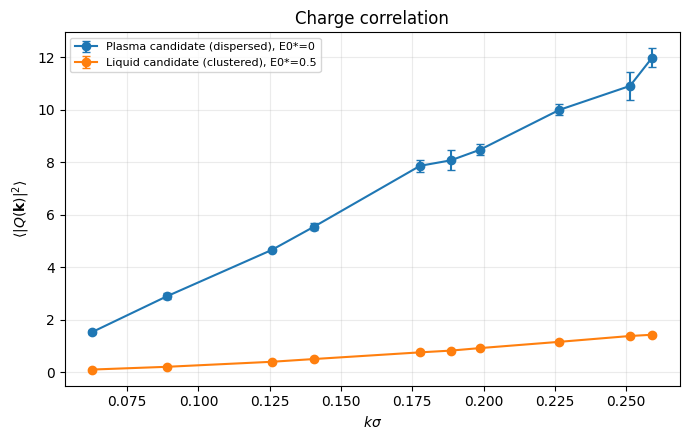

In [32]:
comparison_results = {
    'Plasma candidate (dispersed), E0*=0': correlator_data(
        N=50, rho_star=0.005, T_star=0.35, E0_star=0.0),
    'Liquid candidate (clustered), E0*=0.5': correlator_data(
        N=50, rho_star=0.005, T_star=0.35, E0_star=0.5),
}
comparison_channel = 'charge'          # 或 'charge'
comparison_normalization = 'raw'        # 或 'per_particle'
comparison_x_axis = 'k_sigma'           # 或 'kL'
fig, ax = plt.subplots(figsize=(7, 4.5))
for label, result in comparison_results.items():
    plot_correlator(result, channel=comparison_channel,
                    normalization=comparison_normalization,
                    x_axis=comparison_x_axis, ax=ax, label=label)
plt.show()


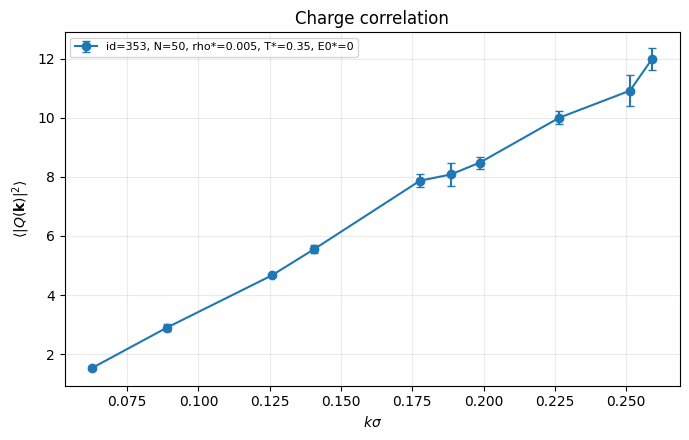

,state_id,m_squared,degeneracy,kL,k_sigma,density,density_sem,charge,charge_sem
0,353,1,4,6.283185,0.062832,88.034918,10.384679,1.541100,0.064554
1,353,2,4,8.885766,0.088858,84.712493,5.284040,2.895381,0.116246
2,353,4,4,12.566371,0.125664,92.658900,9.128347,4.662455,0.022111
3,353,5,8,14.049629,0.140496,92.396097,4.260270,5.549479,0.134340
4,353,8,4,17.771532,0.177715,86.144697,3.487895,7.870995,0.222291
5,353,9,4,18.849556,0.188496,88.338707,2.575394,8.080112,0.382681
6,353,10,8,19.869177,0.198692,89.425295,2.396409,8.482449,0.204709
7,353,13,8,22.654347,0.226543,87.030012,1.941925,10.001471,0.209451
8,353,16,4,25.132741,0.251327,86.552369,4.876774,10.915323,0.530597
9,353,17,8,25.906237,0.259062,87.416331,3.892883,11.986636,0.359150


In [26]:
corr_N = 50
corr_rho_star = 0.005
corr_T_star = 0.35
corr_E0_star = 0.0
corr_state_id = None
corr_replicate_id = 1
corr_channel = 'charge'             # 'density' or 'charge'
corr_normalization = 'raw'           # ‘raw’ or 'per_particle'
corr_x_axis = 'k_sigma'
corr_n_shells = 10
corr_n_blocks = 5
corr_sample_start = 1
corr_sample_stop = None

selected_correlation = correlator_data(
    N=corr_N, rho_star=corr_rho_star, T_star=corr_T_star, E0_star=corr_E0_star,
    state_id=corr_state_id, replicate_id=corr_replicate_id,
    n_shells=corr_n_shells, n_blocks=corr_n_blocks,
    sample_start=corr_sample_start, sample_stop=corr_sample_stop)
plot_correlator(selected_correlation, channel=corr_channel,
                normalization=corr_normalization, x_axis=corr_x_axis)
plt.show()
display(selected_correlation['table'])


In [27]:
def radial_pair_series(xy, q, bins=80, r_max=0.5):
    """单位正方形周期盒；返回边界、逐帧数密度/电荷加权无序对计数。"""
    if isinstance(bins, bool) or not isinstance(bins, Integral) or bins < 1:
        raise ValueError('bins 必须为正整数。')
    if not np.isfinite(r_max) or not 0 < r_max <= 0.5:
        raise ValueError('单位盒中需要 0 < r_max <= 0.5，以保证圆环完整。')
    xy, q = np.asarray(xy), np.asarray(q)
    if q.ndim != 1 or len(q) < 2 or xy.ndim != 3 or xy.shape[1:] != (len(q), 2):
        raise ValueError('需要 xy[frame, particle, 2] 及匹配的 q[particle]，N>=2。')
    if not np.isfinite(xy).all() or not np.isfinite(q).all():
        raise ValueError('坐标和电荷必须为有限数值。')
    edges = np.linspace(0, r_max, bins+1)
    ii, jj = np.triu_indices(len(q), k=1)
    weights = q[ii]*q[jj]
    hn = np.empty((len(xy), bins))
    hq = np.empty_like(hn)
    for t, frame in enumerate(xy):
        delta = frame[ii] - frame[jj]
        delta -= np.rint(delta)
        distance = np.sqrt(np.sum(delta**2, axis=1))
        hn[t] = np.histogram(distance, bins=edges)[0]
        hq[t] = np.histogram(distance, bins=edges, weights=weights)[0]
    return edges, hn, hq


def real_correlator_data(*, N=50, rho_star=0.005, T_star=0.35, E0_star=0.0,
                         state_id=None, replicate_id=1, bins=80, r_max=0.5,
                         n_blocks=5, sample_start=1, sample_stop=None):
    row = select_state(N=N, rho_star=rho_star, T_star=T_star, E0_star=E0_star,
                       state_id=state_id, replicate_id=replicate_id)
    xy, q, samples, production, total = load_animation_data(
        row['batch_dir'], int(row['state_id']), int(row['replicate_id']))
    stop = len(samples) if sample_stop is None else sample_stop
    if (not isinstance(sample_start, Integral) or not isinstance(stop, Integral)
            or not 1 <= sample_start <= stop <= len(samples)):
        raise ValueError(f'需要 1 <= sample_start <= sample_stop <= {len(samples)}。')
    count = stop-sample_start+1
    if (not isinstance(n_blocks, Integral) or isinstance(n_blocks, bool)
            or not 2 <= n_blocks <= count or count % n_blocks):
        raise ValueError('n_blocks 至少为 2，且必须整除所选帧数。')
    edges, hn, hq = radial_pair_series(xy[sample_start-1:stop], q, bins, r_max)
    area = np.pi*np.diff(edges**2)
    n = len(q)
    a = np.sqrt(float(row['rho_star'])/n)
    table = pd.DataFrame({'r_left_over_L': edges[:-1], 'r_right_over_L': edges[1:],
                          'r_over_L': (edges[:-1]+edges[1:])/2})
    table['r_over_sigma'] = table['r_over_L']/a
    table.insert(0, 'state_id', int(row['state_id']))
    series, block_means = {}, {}
    for channel, hist in [('density', hn), ('charge', hq)]:
        for norm, factor in [('g', 2/(n*(n-1)*area)), ('pair_density', 2/area)]:
            key = channel+'_'+norm
            series[key] = hist*factor
            block_means[key] = series[key].reshape(n_blocks, count//n_blocks, bins).mean(axis=1)
            table[key] = series[key].mean(axis=0)
            table[key+'_sem'] = block_means[key].std(axis=0, ddof=1)/np.sqrt(n_blocks)
    # 均匀独立位置、固定电荷数组的参考值，兼容非中性 q。
    charge_baseline = (q.sum()**2-np.sum(q**2))/(n*(n-1))
    return {'parameters': row, 'table': table, 'series': series,
            'block_means': block_means, 'charge_baseline': charge_baseline,
            'samples': samples[sample_start-1:stop],
            'production_sweeps': production[sample_start-1:stop]}


def plot_real_correlator(result, *, channel='density', normalization='g',
                         x_axis='r_over_sigma', ax=None, label=None, reference=True):
    if channel not in ('density', 'charge') or normalization not in ('g', 'pair_density'):
        raise ValueError('channel 选 density/charge；normalization 选 g/pair_density。')
    if x_axis not in ('r_over_sigma', 'r_over_L'):
        raise ValueError('x_axis 选 r_over_sigma/r_over_L。')
    row, table = result['parameters'], result['table']
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4.5))
    if label is None:
        label = (f"id={int(row['state_id'])}, N={int(row['N'])}, "
                 f"rho*={row['rho_star']:g}, T*={row['T_star']:g}, E0*={row['E0_star']:g}")
    key = channel+'_'+normalization
    ax.errorbar(table[x_axis], table[key], yerr=table[key+'_sem'],
                fmt='.-', markersize=4, linewidth=1, capsize=2, label=label)
    sub = 'nn' if channel == 'density' else 'qq'
    ylabel = rf'$g_{{{sub}}}(r)$' if normalization == 'g' else rf'$C_{{{sub}}}(r)\ [L^{{-4}}]$'
    if reference:
        base = 1.0 if channel == 'density' else result['charge_baseline']
        if normalization == 'pair_density':
            base *= int(row['N'])*(int(row['N'])-1)
        ax.axhline(base, color='gray', linestyle='--', linewidth=1, label='Independent-position baseline')
    ax.set(xlabel=r'$r/\sigma$' if x_axis == 'r_over_sigma' else r'$r/L$',
           ylabel=ylabel, title=f'{channel.capitalize()} radial correlation')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
    ax.figure.tight_layout()
    return ax


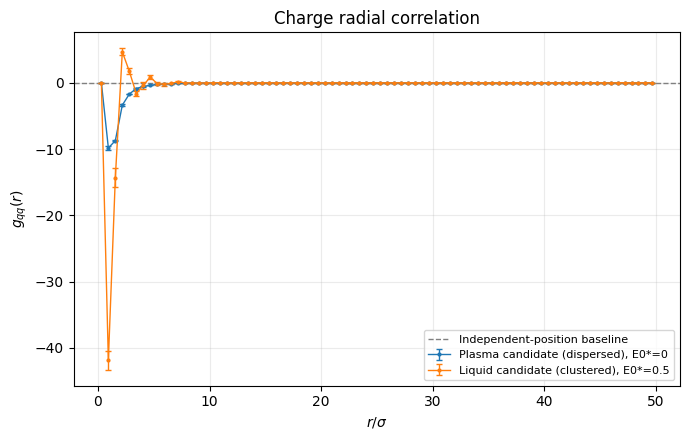

In [31]:
real_comparison_results = {
    'Plasma candidate (dispersed), E0*=0': real_correlator_data(
        N=50, rho_star=0.005, T_star=0.35, E0_star=0.0),
    'Liquid candidate (clustered), E0*=0.5': real_correlator_data(
        N=50, rho_star=0.005, T_star=0.35, E0_star=0.5),
}
real_comparison_channel = 'charge'       # 或 'charge'
real_comparison_normalization = 'g'       # 或 'pair_density'
real_comparison_x_axis = 'r_over_sigma'   # 或 'r_over_L'
fig_real, ax_real = plt.subplots(figsize=(7, 4.5))
for index, (label, result) in enumerate(real_comparison_results.items()):
    plot_real_correlator(result, channel=real_comparison_channel,
                         normalization=real_comparison_normalization,
                         x_axis=real_comparison_x_axis, ax=ax_real, label=label,
                         reference=(index == 0))
plt.show()


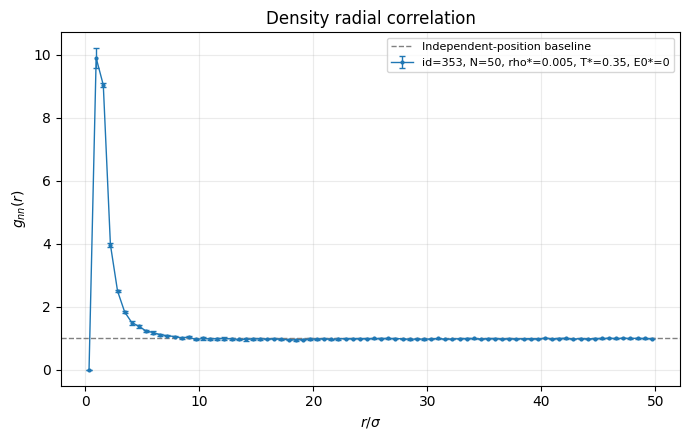

,state_id,r_left_over_L,r_right_over_L,r_over_L,r_over_sigma,density_g,density_g_sem,density_pair_density,density_pair_density_sem,charge_g,charge_g_sem,charge_pair_density,charge_pair_density_sem
0,353,0.00000,0.00625,0.003125,0.3125,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,353,0.00625,0.01250,0.009375,0.9375,9.902651,0.304580,24261.494642,746.221094,-9.840565,0.316867,-24109.384958,776.323357
2,353,0.01250,0.01875,0.015625,1.5625,9.044096,0.070354,22158.035008,172.368339,-8.732781,0.060581,-21395.313591,148.423307
3,353,0.01875,0.02500,0.021875,2.1875,3.970310,0.064933,9727.259096,159.086741,-3.375429,0.122008,-8269.799978,298.918883
4,353,0.02500,0.03125,0.028125,2.8125,2.498206,0.031380,6120.603963,76.880326,-1.708832,0.024250,-4186.637977,59.413426
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,353,0.46875,0.47500,0.471875,47.1875,0.997980,0.007093,2445.051647,17.378444,0.011630,0.005135,28.493583,12.580241
76,353,0.47500,0.48125,0.478125,47.8125,0.992543,0.009095,2431.731080,22.281656,0.001522,0.007610,3.728179,18.645457
77,353,0.48125,0.48750,0.484375,48.4375,0.997032,0.012679,2442.727317,31.063436,-0.001545,0.004482,-3.785218,10.981734
78,353,0.48750,0.49375,0.490625,49.0625,0.992508,0.013300,2431.644236,32.585674,-0.006144,0.001668,-15.051800,4.086827


In [29]:
real_N = 50
real_rho_star = 0.005
real_T_star = 0.35
real_E0_star = 0.0
real_state_id = None
real_replicate_id = 1
real_channel = 'density'            # 或 'charge'
real_normalization = 'g'            # 或 'pair_density'
real_x_axis = 'r_over_sigma'        # 或 'r_over_L'
real_bins = 80
real_r_max = 0.5                    # 单位 r/L，最大 0.5
real_n_blocks = 5
real_sample_start = 1
real_sample_stop = None

selected_real_correlation = real_correlator_data(
    N=real_N, rho_star=real_rho_star, T_star=real_T_star, E0_star=real_E0_star,
    state_id=real_state_id, replicate_id=real_replicate_id,
    bins=real_bins, r_max=real_r_max, n_blocks=real_n_blocks,
    sample_start=real_sample_start, sample_stop=real_sample_stop)
plot_real_correlator(selected_real_correlation, channel=real_channel,
                     normalization=real_normalization, x_axis=real_x_axis)
plt.show()
display(selected_real_correlation['table'])
# display(pd.DataFrame(selected_real_correlation['block_means'][real_channel+'_'+real_normalization]))


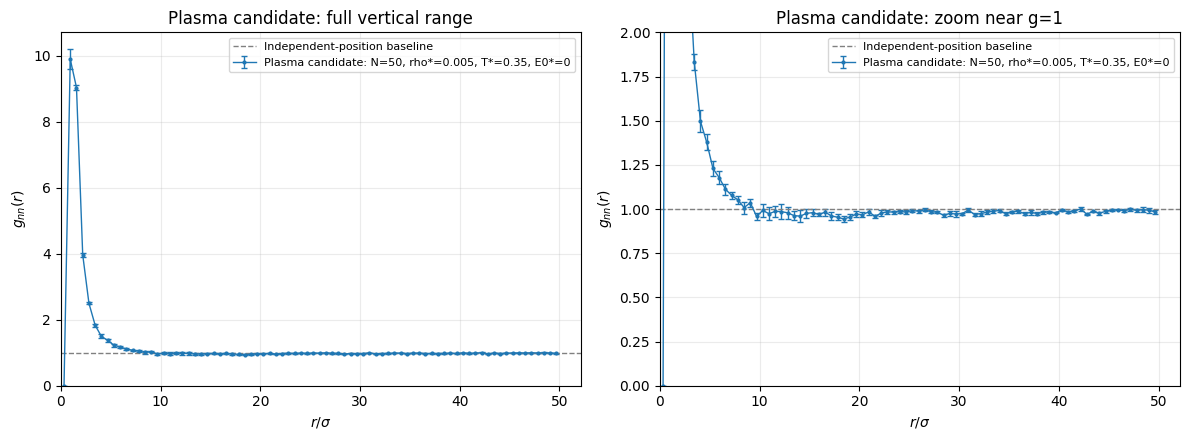

In [30]:
plasma_detail = real_correlator_data(
    N=50, rho_star=0.005, T_star=0.35, E0_star=0.0,
    bins=80, r_max=0.5, n_blocks=5)
fig_plasma, axes_plasma = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
for ax in axes_plasma:
    plot_real_correlator(
        plasma_detail, channel='density', normalization='g',
        x_axis='r_over_sigma', ax=ax,
        label='Plasma candidate: N=50, rho*=0.005, T*=0.35, E0*=0')
    ax.set_xlim(left=0)
axes_plasma[0].set_title('Plasma candidate: full vertical range')
axes_plasma[0].set_ylim(bottom=0)
axes_plasma[1].set_title('Plasma candidate: zoom near g=1')
axes_plasma[1].set_ylim(0, 2)
fig_plasma.tight_layout()
plt.show()
